# **"Titanic Survival Analysis project"**

**name and id**

**mariz emad william     20245044**

**farah ebrahim farouk   20245041**

**Import Libraries and Load Dataset**

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from scipy.stats import zscore

In [65]:
from google.colab import files                 ## upload data(train.csv)
uploaded = files.upload()

Saving train.csv to train (2).csv


In [66]:
dataset = pd.read_csv('train.csv')

In [67]:
print("Dataset Shape(rows,columns):", dataset.shape)
dataset.head()

Dataset Shape(rows,columns): (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Q1.1 — Inspect the data**

In [68]:
print("Shape of dataset:")
print(dataset.shape)

Shape of dataset:
(891, 12)


In [69]:
print("Data types:")
display(dataset.dtypes)

Data types:


,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [70]:
missing_count = dataset.isnull().sum()
missing_percent = (missing_count / len(dataset)) * 100

missing_dataset = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage': missing_percent
})
missing_dataset['Percentage'] = missing_dataset['Percentage'].round(2).astype(str) + '%'

display(missing_dataset)

,Missing Values,Percentage
PassengerId,0,0.0%
Survived,0,0.0%
Pclass,0,0.0%
Name,0,0.0%
Sex,0,0.0%
Age,177,19.87%
SibSp,0,0.0%
Parch,0,0.0%
Ticket,0,0.0%
Fare,0,0.0%


# **Q1.2 — Handle Missing Values in Age**

In [71]:
group_medians = dataset.groupby(['Pclass', 'Sex'])['Age'].median()

print("Median ages used:")
display(group_medians)

Median ages used:


Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [ ]:
dataset['Age'] = dataset.groupby(['Pclass', 'Sex'])['Age'] \
              .transform(lambda x: x.fillna(x.median()))

In [ ]:
remaining_missing = dataset['Age'].isna().sum()

if remaining_missing > 0:
    print("Yes")
else:
    print("No")

No


**to make double check by another way About the NAN values**

In [ ]:
print("Yes" if dataset['Age'].isna().sum() > 0 else "No")

No


# **Q1.3 — Handle Embarked and Fare**

*  handle nulls in embarked column
*   handle nulls in fare colunm


---







In [74]:
embarked_mode = dataset['Embarked'].mode()[0]
dataset['Embarked'] = dataset['Embarked'].fillna(embarked_mode)
display("Embarked mode used:", embarked_mode)

'Embarked mode used:'

'S'

In [75]:
dataset['Fare'] = dataset.groupby('Pclass')['Fare'] \
               .transform(lambda x: x.fillna(x.median()))

**check if the fare or Embarked colunm have nulls vales**

In [76]:
print("Remaining Fare missing values:")
print(dataset['Fare'].isna().sum())

Remaining Fare missing values:
0


In [77]:
print("Remaining Embarked missing values:")
print(dataset['Embarked'].isna().sum())

Remaining Embarked missing values:
0


# **Q1.4 — Encode categorical variables**

In [ ]:
dataset['Sex'] = dataset['Sex'].map({
    'female': 0,
    'male': 1
})

In [ ]:
dataset['Embarked'] = dataset['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

In [ ]:
print("Sex value counts:")                             ## to check we sum  the output(577+314) the result is 891 s0 the same count of rows so there is no nulls
display(dataset['Sex'].value_counts())

Sex value counts:


,count
Sex,
1,577
0,314


In [ ]:
print("Embarked value counts:")                       ## to check we sum  the output(646+168+77) the result is 891 s0 the same count of rows so there is no nulls
display(dataset['Embarked'].value_counts())

Embarked value counts:


,count
Embarked,
0,646
1,168
2,77


# **Q1.5 — Engineer new features(Create three new columns)**

**Title colunm**

In [79]:
dataset['Title'] = dataset['Name'].str.extract(' ([A-Za-z]+)', expand=False)

In [80]:
dataset['Title'] = dataset['Title'].replace([
    'Lady', 'Countess', 'Capt', 'Col',
    'Don', 'Dr', 'Major', 'Rev',
    'Sir', 'Jonkheer', 'Dona'
], 'Rare')

In [81]:
dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')


In [82]:
title_mapping = {
    'Mr': 1,
    'Miss': 2,
    'Mrs': 3,
    'Master': 4,
    'Rare': 5
}

In [83]:
dataset['Title'] = dataset['Title'].map(title_mapping)

In [84]:
dataset['Title'] = dataset['Title'].fillna(0).astype(int)

In [85]:
display(dataset['Title'])

,Title
0,1
1,3
2,2
3,3
4,1
...,...
886,5
887,2
888,2
889,1


**Create FamilySize column**

In [95]:
dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1
display(dataset['FamilySize'])

,FamilySize
0,2
1,2
2,1
3,2
4,1
...,...
886,1
887,1
888,4
889,1


**IsAlone column**

In [88]:
dataset['IsAlone'] = np.where(dataset['FamilySize'] == 1, 1, 0)
display(dataset['IsAlone'])

,IsAlone
0,0
1,0
2,1
3,0
4,1
...,...
886,1
887,1
888,0
889,1


**to check what we did**

In [ ]:
display(dataset[['Name', 'Title', 'SibSp', 'Parch',
          'FamilySize', 'IsAlone']].head(10))

,Name,Title,SibSp,Parch,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",1,1,0,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",3,1,0,2,0
2,"Heikkinen, Miss. Laina",2,0,0,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",3,1,0,2,0
4,"Allen, Mr. William Henry",1,0,0,1,1
5,"Moran, Mr. James",1,0,0,1,1
6,"McCarthy, Mr. Timothy J",1,0,0,1,1
7,"Palsson, Master. Gosta Leonard",4,3,1,5,0
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",3,0,2,3,0
9,"Nasser, Mrs. Nicholas (Adele Achem)",3,1,0,2,0


# **Q1.6 — Pearson correlation heatmap**

In [ ]:
corr_matrix = dataset.corr(numeric_only=True)


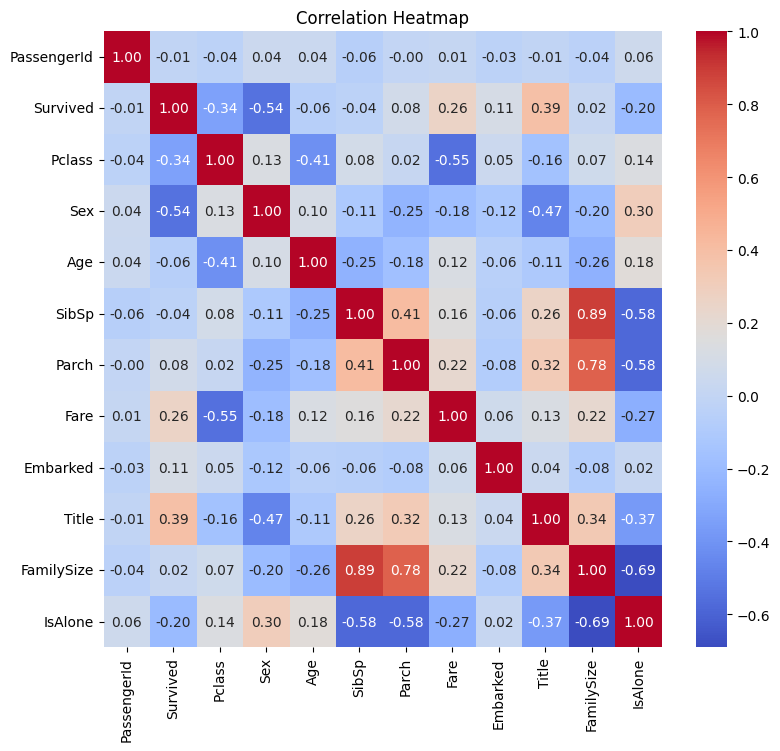

In [89]:
plt.figure(figsize=(9,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

Answer

The two features most related to Survived are usually:

Sex (strong negative correlation because male = 1 and females survived more)
Pclass (negative correlation because first-class passengers survived more often)


Explanation
Women and children were prioritized during evacuation.
Higher-class passengers had better cabin locations and easier access to lifeboats.

# **Q1.7— Predict Fare with linear regression(machine learing)**

**perpare data before training**

In [ ]:
X = dataset[['Pclass']]
y = dataset['Fare']

**Train Model**

In [90]:
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

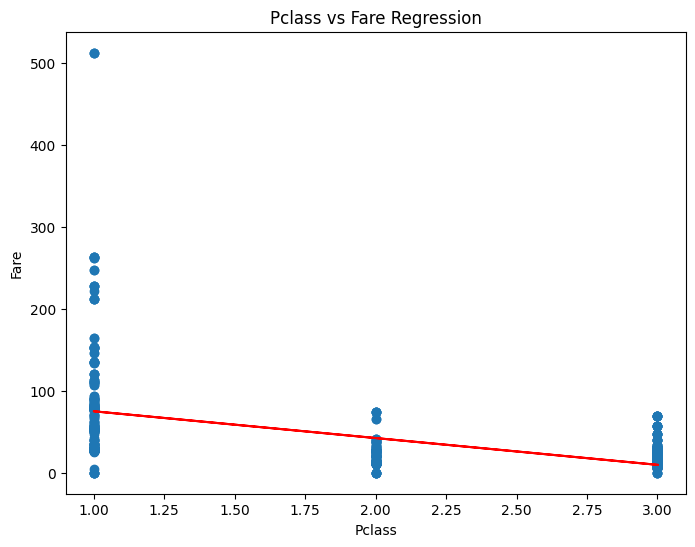

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(dataset['Pclass'], dataset['Fare'])


plt.plot(dataset['Pclass'], y_pred,color='red')

plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.title("Pclass vs Fare Regression")

plt.show()

In [ ]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: -32.66051837394824
Intercept: 107.6056516220107


Answer

Fare generally decreases as Pclass increases.

Explanation:

Pclass = 1 is first class (most expensive)
Pclass = 3 is third class (cheapest)

So higher class number means lower ticket price.

# **Q1.8 — IQR and Z-score outlier detection on Fare**

1.   two methods to find outliers in the Fare column
2.   Create two box plots side by side




**IQR method**

In [ ]:
Q1 = dataset['Fare'].quantile(0.25)
Q3 = dataset['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = dataset[
    (dataset['Fare'] < lower_bound) |
    (dataset['Fare'] > upper_bound)
]

print("IQR Lower Bound:", lower_bound)
print("IQR Upper Bound:", upper_bound)

print("Number of IQR outliers:", len(iqr_outliers))

IQR Lower Bound: -26.724
IQR Upper Bound: 65.6344
Number of IQR outliers: 116


**Z-Score Method**

In [ ]:
z_scores = zscore(dataset['Fare'])

In [93]:
threshold = 3
z_outliers = dataset[np.abs(z_scores) > threshold]
print("Z-score Threshold:", threshold)
print("Number of Z-score outliers:", len(z_outliers))

Z-score Threshold: 3
Number of Z-score outliers: 20


**compare between them**

In [ ]:
print("IQR Outliers:", len(iqr_outliers))
print("Z-score Outliers:", len(z_outliers))

IQR Outliers: 116
Z-score Outliers: 20


Answer



Usually:IQR detects more outliers
Z-score is stricter because it assumes near-normal distribution

Since Fare is heavily right-skewed, IQR often performs better.

# **(Bonus)**

**Top 5 Fare Outliers**

In [ ]:
top_outliers = iqr_outliers.sort_values(
    by='Fare',
    ascending=False
)[['Name', 'Pclass', 'Fare', 'Survived']]

display(top_outliers.head())

,Name,Pclass,Fare,Survived
258,"Ward, Miss. Anna",1,512.3292,1
737,"Lesurer, Mr. Gustave J",1,512.3292,1
679,"Cardeza, Mr. Thomas Drake Martinez",1,512.3292,1
27,"Fortune, Mr. Charles Alexander",1,263.0000,0
341,"Fortune, Miss. Alice Elizabeth",1,263.0000,1


**two box plots side by side**

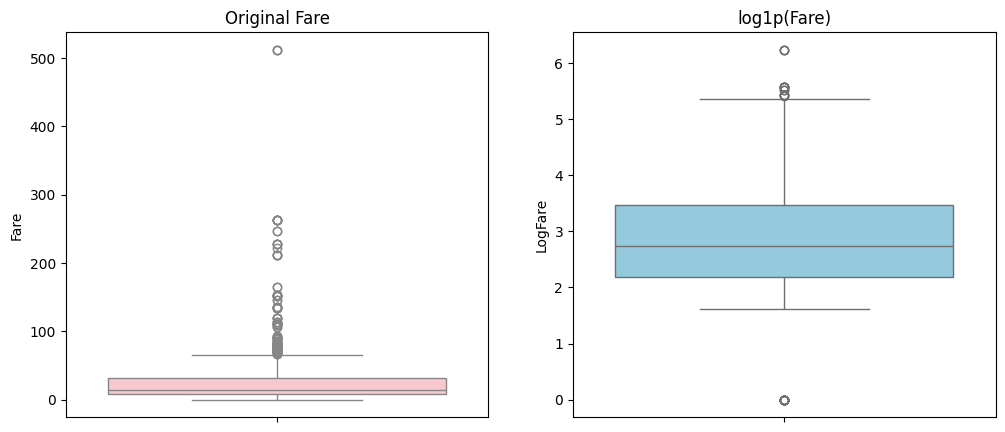

In [ ]:
dataset['LogFare'] = np.log1p(dataset['Fare'])
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(y=dataset['Fare'], ax=axes[0],color='pink')
axes[0].set_title("Original Fare")
sns.boxplot(y=dataset['LogFare'], ax=axes[1],color='skyblue')
axes[1].set_title("log1p(Fare)")

plt.show()

In [ ]:
display(dataset.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,FamilySize,IsAlone,LogFare
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0,1,2,0,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,1,3,2,0,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0,2,1,1,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,0,3,2,0,3.990834
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0,1,1,1,2.202765
